# MATH70113_NB_Final

# MATH70113 – Simulation Methods for Finance
## Group Coursework — Jupyter Notebook

**Group members:**
| Name | CID |
|---|---|
| Paul Archer | 06054057 |
| Hamza El Arji | 06020926 |
| Chedi Mnif | 06064588 |
| Diane Murzi | 06048769 |

This notebook generates all numerical results and figures in the report.  
It is designed to run on **Google Colab with a T4 GPU (15 GB VRAM)** using [CuPy](https://cupy.dev/) for GPU acceleration. If no GPU is available, it falls back to NumPy automatically (slower but correct).

**Key implementation choices:**
- `xp` namespace — resolves to CuPy (GPU) or NumPy (CPU) at runtime
- `float32` arithmetic — halves memory use and roughly doubles GPU throughput vs `float64`
- Shared-Z sweeps — a single draw of Gaussian increments is reused across all parameter values in each sweep (×10 speedup)
- One-pass MSE (Part 2) — a single reference run at $N_{\text{ref}}$ paths; all columns of the MSE table follow from the exact identity $\text{MSE}(N) = \text{MSE}(N_{\text{ref}}) \times N_{\text{ref}} / N$
- `joblib.Parallel` — Longstaff–Schwartz trials are parallelised across CPU cores

**Estimated runtimes on a T4 GPU:**
| Section | Time |
|---|---|
| Part 1 (all) | ~5–10 s |
| Part 2 — MSE tables | ~15–20 s |
| Part 2 — LSM grid | ~45 s |
| **Total** | **~1 min** |

&nbsp;

> **Cells 14b and 14c are commented out.** They implement two additional convergence experiments (brute-force $N = 10^9$ run and Richardson extrapolation) that we ran separately to verify that the Brownian bridge bias lies below the Monte Carlo noise floor at all practical sample sizes. Cell 14b in particular takes $\approx$ 20 minutes even on a GPU and is included for reference only.

In [1]:
import numpy as np
import math, time, warnings
from concurrent.futures import ProcessPoolExecutor
from scipy.stats import norm
from scipy.special import eval_laguerre, comb
from scipy.differentiate import derivative as _scipy_deriv
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LogNorm
import gc
import time
from joblib import Parallel, delayed
warnings.filterwarnings('ignore')

# GPU detection
try:
    import cupy as cp
    xp = cp
    # Warm up GPU
    _ = cp.array([1.0])
    props = cp.cuda.runtime.getDeviceProperties(0)
    mem   = cp.cuda.runtime.memGetInfo()
    print(f"GPU detected: {props['name'].decode()}")
    print(f"  VRAM: {props['totalGlobalMem']/1e9:.1f} GB  |  Free: {mem[0]/1e9:.1f} GB")
    DEVICE = 'GPU'
    # Chunk size for batched GPU operations — reduce if OOM
    GPU_CHUNK = min(200, int(mem[0] / (128_000 * 4 * 8)))  # auto-tune
    print(f"  Auto-tuned batch chunk: {GPU_CHUNK}")
except Exception as e:
    import numpy as cp   # cp becomes an alias for numpy
    xp = np
    DEVICE = 'CPU'
    GPU_CHUNK = 50
    print(f'No GPU / CuPy — running on CPU. (reason: {e})')
    print('Install CuPy: pip install cupy-cuda11x  (or cupy-cuda12x)')

def to_numpy(arr):
    """Transfer CuPy array to host NumPy array (no-op if already NumPy)."""
    return cp.asnumpy(arr) if DEVICE == 'GPU' else np.asarray(arr)

def f32(x):
    """Cast scalar to xp float32."""
    return xp.float32(x)

plt.rcParams.update({'figure.dpi': 130, 'font.size': 11,
                     'axes.grid': True, 'grid.alpha': 0.3})
SAVEFIG_KW = dict(dpi=150, bbox_inches='tight')
SEED = 42
print(f'\nRunning on {DEVICE}. All seeds fixed to {SEED}.')

GPU detected: Tesla T4
  VRAM: 15.6 GB  |  Free: 15.5 GB
  Auto-tuned batch chunk: 200

Running on GPU. All seeds fixed to 42.


---
# Part 1 — Pathwise Greeks for a Down-and-Out Barrier Call

We estimate $\Delta$ (Delta) and $\mathcal{V}$ (Vega) of a down-and-out barrier call option under GBM using the **pathwise sensitivity method** with a **Brownian bridge barrier correction**. All mathematical derivations are in the report (Section 2).

## 1.0  Problem Statement

The underlying asset $S$ follows Geometric Brownian Motion under the risk-neutral measure:

$$dS_t = r\,S_t\,dt + \sigma\,S_t\,dW_t, \quad t \in [0,T], \quad S_0 = s_0.$$

The down-and-out barrier call has the discounted payoff:

$$V = \mathbb{E}\left[e^{-rT}(S_T - K)^+ \,\mathbf{1}_{\{\min_{t \in [0,T]} S_t > B\}}\right].$$

**Parameters used throughout this notebook:** $r=0.05$, $\sigma=0.5$, $T=1$, $s_0=100$, $K=110$, $B=90$.

**Goal:** Estimate $\Delta = \partial V/\partial s_0$ and $\mathcal{V} = \partial V/\partial \sigma$ using the **pathwise (IPA) method** combined with the **Brownian-bridge barrier crossing correction** (Glasserman §6.4).

In [2]:
r = 0.05;  sigma = 0.5;  T = 1.0
s0 = 100.0;  K_opt = 110.0;  B_base = 90.0

N_MAIN  = 500_000   # paths for the main run
N_SWEEP = 200_000   # paths for parameter sweeps (S0, sigma, B)
M_STEPS = 252       # daily discretisation

def num_deriv(f, x0, dx=1e-5):
    """
    Fourth-order central finite difference.
    Coefficients: [-1/12, 2/3, 0, -2/3, 1/12] / dx
    Error = O(dx^4) ~ 1e-20 for dx=1e-5 — negligible vs MC noise.
    Works with any scalar-valued function, no vectorisation required.
    """
    return (-f(x0 + 2*dx) + 8*f(x0 + dx) - 8*f(x0 - dx) + f(x0 - 2*dx)) / (12*dx)

def do_call_price(s, K, B, r, sigma, T):
    """Closed-form down-and-out barrier call price (Black-Scholes)."""
    lam = (r + 0.5*sigma**2) / sigma**2
    sqT = sigma * np.sqrt(T)
    x1  = np.log(s/K) / sqT + lam*sqT
    y1  = np.log(B**2/(s*K)) / sqT + lam*sqT
    return (s*norm.cdf(x1) - K*np.exp(-r*T)*norm.cdf(x1-sqT)
            - s*(B/s)**(2*lam)*norm.cdf(y1)
            + K*np.exp(-r*T)*(B/s)**(2*lam-2)*norm.cdf(y1-sqT))

eps_s, eps_v = 0.5, 0.002
V_exact     = do_call_price(s0, K_opt, B_base, r, sigma, T)
Delta_exact = num_deriv(lambda s: do_call_price(s, K_opt, B_base, r, sigma, T), s0)
Vega_exact  = num_deriv(lambda v: do_call_price(s0, K_opt, B_base, r, v, T),    sigma)

print(f'Exact price: {V_exact:.6f}  |  Delta: {Delta_exact:.6f}  |  Vega: {Vega_exact:.6f}')

Exact price: 8.595814  |  Delta: 0.849357  |  Vega: 4.550661


## 1.0.1  The Brownian-Bridge Correction (Glasserman §6.4)

We simulate $S$ on a grid $0 = t_0 < t_1 < \cdots < t_n = T$ with step $h = T/n$ via the exact log-Euler scheme:

$$\log S_{t_{k+1}} = \log S_{t_k} + \left(r - \tfrac{1}{2}\sigma^2\right)h + \sigma\sqrt{h}\,Z_{k+1}, \quad Z_k \sim \mathcal{N}(0,1).$$

A naive check $\min_k S_{t_k} > B$ introduces **discretisation bias** because the path may cross $B$ between grid points. The Brownian-bridge correction fixes this by replacing the binary indicator with the **conditional survival probability** given the endpoints.

Conditioned on $S_{t_k} > B$ and $S_{t_{k+1}} > B$, the probability that the continuous GBM path crosses the barrier in $[t_k, t_{k+1}]$ is:

$$\hat{p}_k = \exp\!\left(-\frac{2\,(\log S_{t_k} - \log B)(\log S_{t_{k+1}} - \log B)}{\sigma^2 h}\right).$$

The per-interval survival probability is $\hat{q}_k = 1 - \hat{p}_k$, and the path-level weight is:

$$W = \prod_{k=0}^{n-1} \hat{q}_k.$$

The conditional Monte Carlo estimator (Glasserman Eq. 6.55) replaces the binary indicator $\mathbf{1}\{\tau > T\}$ with $W$:

$$\hat V = \frac{1}{N}\sum_{j=1}^{N} e^{-rT}(S_T^{(j)} - K)^+ \,W^{(j)}.$$

**Why this works.** Conditioning on the simulated Gaussian increments $X = (Z_1,\dots,Z_n)$ and using the tower property:

$$V = \mathbb{E}\left[e^{-rT}(S_T-K)^+ \,\mathbb{E}[\mathbf{1}_{\{\tau > T\}} \mid X]\right] = \mathbb{E}\left[e^{-rT}(S_T-K)^+ W(X)\right]$$

since $S_T$ is fully determined by $X$ and only the survival is random conditionally. This achieves $\mathcal{O}(h)$ weak convergence (vs $\mathcal{O}(\sqrt{h})$ for the naive estimator) and, crucially, makes the payoff a **smooth function** of the parameters — enabling pathwise differentiation.

## 1.0.2  Pathwise Delta: $\Delta = \partial V / \partial s_0$

Differentiating the per-path estimator $f = e^{-rT}(S_T - K)^+ W$ via the product rule:

$$\frac{\partial f}{\partial s_0} = e^{-rT}\left[\mathbf{1}_{\{S_T > K\}}\frac{\partial S_T}{\partial s_0}\,W + (S_T - K)^+\frac{\partial W}{\partial s_0}\right].$$

**Term 1 — terminal price derivative.** Since $\log S_T = \log s_0 + (r - \tfrac{1}{2}\sigma^2)T + \sigma W_T$:

$$\frac{\partial S_T}{\partial s_0} = \frac{S_T}{s_0}.$$

**Term 2 — survival weight derivative.** Using $\partial W / \partial s_0 = W \sum_k \frac{1}{\hat q_k}\frac{\partial \hat q_k}{\partial s_0}$, and the fact that $\partial(\log S_{t_k})/\partial s_0 = 1/s_0$ for all $k$ (since $s_0$ enters additively in log-space):

$$\frac{\partial \hat p_k}{\partial s_0} = \hat p_k\left(-\frac{2}{\sigma^2 h}\right)\frac{l_k + l_{k+1}}{s_0}, \qquad l_k = \log S_{t_k} - \log B,$$

so $\partial \hat q_k/\partial s_0 = -\partial \hat p_k/\partial s_0$. Both terms are **non-negligible**, and we verify in Section 1.3 that Term 2 contributes a non-trivial fraction of the total Delta.

## 1.0.3  Pathwise Vega: $\mathcal{V} = \partial V / \partial \sigma$

Same product rule:

$$\frac{\partial f}{\partial \sigma} = e^{-rT}\left[\mathbf{1}_{\{S_T > K\}}\frac{\partial S_T}{\partial \sigma}\,W + (S_T - K)^+\frac{\partial W}{\partial \sigma}\right].$$

**Term 1 — terminal price derivative.** From $\log S_{t_k} = \log s_0 + (r - \tfrac{1}{2}\sigma^2)kh + \sigma\sqrt{h}\sum_{j=1}^{k} Z_j$:

$$\frac{\partial \log S_{t_k}}{\partial \sigma} = -\sigma kh + \sqrt{h}\sum_{j=1}^{k} Z_j,$$

and $\partial S_T/\partial \sigma = S_T \cdot (\partial \log S_T / \partial \sigma)$.

**Term 2 — survival weight derivative.** With $l_k = \log S_{t_k} - \log B$:

$$\frac{\partial \hat p_k}{\partial \sigma} = \hat p_k\left[\frac{4\,l_k\,l_{k+1}}{\sigma^3 h} - \frac{2}{\sigma^2 h}\left(\frac{\partial \log S_{t_k}}{\partial \sigma}\,l_{k+1} + l_k\,\frac{\partial \log S_{t_{k+1}}}{\partial \sigma}\right)\right],$$

then $\partial \hat q_k / \partial \sigma = -\partial \hat p_k / \partial \sigma$, and the log-derivative chain gives $\partial W / \partial \sigma = W\sum_k (\partial \hat q_k / \partial \sigma)/\hat q_k$. The cell below implements both terms in vectorised form.

In [3]:
# Core MC function — GPU-ready via xp namespace + float32

def mc_barrier_pathwise(N, n, s0, r, sigma, T, B, K_s, seed=SEED,
                        _Z=None, _cumZ=None):
    """
    Pathwise Delta & Vega for a down-and-out barrier call.

    OPTIMISATION: if pre-generated (_Z, _cumZ) are supplied,
    they are reused — enables shared-Z sweeps (x10 speedup).

    Returns dict with price/delta/vega + standard errors.
    """
    h      = np.float32(T / n)
    sqrt_h = np.float32(np.sqrt(h))
    disc   = np.float32(np.exp(-r * T))
    lnB    = np.float32(np.log(B))
    s0f    = np.float32(s0)
    rf     = np.float32(r);  sf = np.float32(sigma)

    # Random numbers (reuse if supplied)
    if _Z is None:
        rng = xp.random.default_rng(seed) if hasattr(xp, 'random') else None
        if rng:
            _Z = rng.standard_normal((N, n)).astype(xp.float32)
        else:
            xp.random.seed(seed)
            _Z = xp.random.standard_normal((N, n)).astype(xp.float32)
    if _cumZ is None:
        _cumZ = xp.cumsum(_Z, axis=1)  # (N, n) — shared across sigma values

    # Simulate GBM paths
    log_inc = (rf - 0.5*sf*sf)*h + sf*sqrt_h*_Z   # (N, n)
    cumlog  = xp.cumsum(log_inc, axis=1)            # (N, n)
    logS    = xp.log(s0f) + cumlog                  # (N, n)
    S       = xp.exp(logS)                          # (N, n)

    logS_prev = xp.empty_like(logS)
    logS_prev[:, 0]  = xp.log(s0f)
    logS_prev[:, 1:] = logS[:, :-1]

    # Brownian-bridge survival weights
    l_prev     = logS_prev - lnB
    l_curr     = logS      - lnB
    both_above = (l_prev > 0) & (l_curr > 0)

    exp_arg = xp.float32(-2.0) * l_prev * l_curr / (sf*sf*h)
    p_cross = xp.where(both_above, xp.exp(exp_arg), xp.float32(1.0))
    q_surv  = xp.where(both_above, xp.float32(1.0) - p_cross, xp.float32(0.0))

    with np.errstate(divide='ignore'):
        log_q = xp.where(q_surv > 0,
                         xp.log(xp.maximum(q_surv, xp.float32(1e-38))),
                         xp.float32(-1e30))
    log_W = log_q.sum(axis=1)
    W     = xp.where(log_W > xp.float32(-1e29), xp.exp(log_W), xp.float32(0.0))

    # Payoff
    ST     = S[:, -1]
    payoff = xp.maximum(ST - xp.float32(K_s), xp.float32(0.0))
    itm    = (ST > xp.float32(K_s)).astype(xp.float32)
    f      = disc * payoff * W

   # Pathwise Delta (full product rule, both terms)
    dST_ds0     = ST / s0f
    dp_ds0      = xp.where(both_above,
                           p_cross * (xp.float32(-2.0)/(sf*sf*h)) * (l_curr + l_prev) / s0f,
                           xp.float32(0.0))
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio_s = xp.where(q_surv > 0, -dp_ds0 / q_surv, xp.float32(0.0))
    dW_ds0       = W * ratio_s.sum(axis=1)
    delta_term1  = disc * itm * dST_ds0 * W          # term 1 only (biased if used alone)
    delta_term2  = disc * payoff * dW_ds0             # product-rule correction
    delta_paths  = delta_term1 + delta_term2

    # Pathwise Vega (full product rule, both terms)
    k_idx       = xp.arange(1, n+1, dtype=xp.float32)
    dlogS_dsig  = -sf * (k_idx * h) + sqrt_h * _cumZ
    dlogS_prev  = xp.empty_like(dlogS_dsig)
    dlogS_prev[:, 0]  = xp.float32(0.0)
    dlogS_prev[:, 1:] = dlogS_dsig[:, :-1]

    dST_dsig    = ST * dlogS_dsig[:, -1]
    dp_dsig     = xp.where(both_above,
        p_cross * (xp.float32(4.0)*l_prev*l_curr/(sf*sf*sf*h)
                   - (xp.float32(2.0)/(sf*sf*h)) *
                     (dlogS_prev*l_curr + l_prev*dlogS_dsig)),
        xp.float32(0.0))
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio_v = xp.where(q_surv > 0, -dp_dsig / q_surv, xp.float32(0.0))
    dW_dsig     = W * ratio_v.sum(axis=1)
    vega_term1  = disc * itm * dST_dsig * W
    vega_paths  = vega_term1 + disc * payoff * dW_dsig

    def _stats(arr):
        a = to_numpy(arr).astype(np.float64)
        return float(a.mean()), float(a.std(ddof=1) / np.sqrt(N))

    p, pse = _stats(f)
    d, dse = _stats(delta_paths)
    v, vse = _stats(vega_paths)

    # term1_d / term1_v stored as means only (no memory overhead)
    return dict(price=p, price_se=pse,
                delta=d, delta_se=dse,
                vega=v,  vega_se=vse,
                term1_d=float(to_numpy(delta_term1).astype(np.float64).mean()),
                term1_v=float(to_numpy(vega_term1 ).astype(np.float64).mean()),
                f=f, delta_raw=delta_paths, vega_raw=vega_paths)


def mc_barrier_naive(N, n, s0, r, sigma, T, B, K_s, seed=SEED, _Z=None):
    h   = np.float32(T/n)

    if _Z is None:
        xp.random.seed(seed)
        Z = xp.random.standard_normal((N, n)).astype(xp.float32)
    else:
        Z = _Z

    logS = xp.log(xp.float32(s0)) + xp.cumsum(
        (np.float32(r)-np.float32(0.5*sigma**2))*h + np.float32(sigma)*np.float32(np.sqrt(h))*Z,
        axis=1)
    S    = xp.exp(logS)
    surv = (S > xp.float32(B)).all(axis=1).astype(xp.float32)
    f    = np.float32(np.exp(-r*T)) * xp.maximum(S[:,-1] - xp.float32(K_s), xp.float32(0.0)) * surv
    fa   = to_numpy(f).astype(np.float64)
    return float(fa.mean()), float(fa.std(ddof=1)/np.sqrt(N))


print('Part 1 MC functions defined (GPU-ready, float32, shared-Z capable).')

Part 1 MC functions defined (GPU-ready, float32, shared-Z capable).


## 1.1  Reference Values and Main Simulation

The Black–Scholes closed-form price of a down-and-out barrier call is used as a reference. Delta and Vega references are obtained by fourth-order centred finite differences on this formula (step $h = 10^{-5}$, error $< 10^{-10}$).

The main run uses $N = 5 \times 10^5$ paths, $M = 252$ daily steps, seed 42.

In [4]:
t0 = time.perf_counter()
res = mc_barrier_pathwise(N_MAIN, M_STEPS, s0, r, sigma, T, B_base, K_opt, seed=SEED)
t_main = time.perf_counter() - t0

print(f'Main run ({N_MAIN:,} paths, {M_STEPS} steps): {t_main:.2f}s  [{DEVICE}]')
print('='*66)
print(f"{'Quantity':<12} {'Exact/FD':>12} {'MC':>12} {'95% CI':>24}")
print('-'*66)
ci = lambda m, se: f'[{m-1.96*se:.5f}, {m+1.96*se:.5f}]'
for label, exact, mc_val, mc_se in [
    ('Price',  V_exact,     res['price'], res['price_se']),
    ('Delta',  Delta_exact, res['delta'], res['delta_se']),
    ('Vega',   Vega_exact,  res['vega'],  res['vega_se']),
]:
    print(f"{label:<12} {exact:>12.6f} {mc_val:>12.6f} {ci(mc_val, mc_se):>24}")
print('='*66)

Main run (500,000 paths, 252 steps): 0.52s  [GPU]
Quantity         Exact/FD           MC                   95% CI
------------------------------------------------------------------
Price            8.595814     8.553893       [8.47038, 8.63740]
Delta            0.849357     0.848081       [0.83416, 0.86200]
Vega             4.550661     4.435644       [4.06025, 4.81104]


## 1.2  Parameter Sweeps — Shared-Z Optimisation

All three sweeps ($S_0$, $\sigma$, $B$) reuse the **same matrix of Gaussian increments** $Z \in \mathbb{R}^{N \times M}$. This works because the log-price increment $\Delta \log S_i = (r - \tfrac{\sigma^2}{2})h + \sigma\sqrt{h}\,Z_i$ depends linearly on $Z_i$, so changing $s_0$ or $\sigma$ does not require re-drawing $Z$.

In [5]:
# Pre-generate shared random numbers
t0 = time.perf_counter()

if hasattr(xp, 'random') and hasattr(xp.random, 'default_rng'):
    rng_sw = xp.random.default_rng(SEED)
    Z_shared   = rng_sw.standard_normal((N_SWEEP, M_STEPS)).astype(xp.float32)
else:
    xp.random.seed(SEED)
    Z_shared   = xp.random.standard_normal((N_SWEEP, M_STEPS)).astype(xp.float32)

cumZ_shared = xp.cumsum(Z_shared, axis=1)  # shape (N_SWEEP, M_STEPS)
t_gen = time.perf_counter() - t0
print(f'Shared Z generated ({N_SWEEP:,} paths, {M_STEPS} steps): {t_gen:.2f}s')

# S0 sweep
s0_vals = np.linspace(92, 150, 30)
t0 = time.perf_counter()
res_s0 = [mc_barrier_pathwise(N_SWEEP, M_STEPS, s, r, sigma, T, B_base, K_opt,
                               _Z=Z_shared, _cumZ=cumZ_shared)
          for s in s0_vals]
t_s0 = time.perf_counter() - t0
print(f'S0 sweep (30 values, shared Z): {t_s0:.2f}s  [{DEVICE}]')

# Sigma sweep
sigma_vals = np.linspace(0.15, 0.90, 25)
t0 = time.perf_counter()
res_sig = [mc_barrier_pathwise(N_SWEEP, M_STEPS, s0, r, sv, T, B_base, K_opt,
                                _Z=Z_shared, _cumZ=cumZ_shared)
           for sv in sigma_vals]
t_sig = time.perf_counter() - t0
print(f'Sigma sweep (25 values, shared Z): {t_sig:.2f}s  [{DEVICE}]')

# B sweep
B_vals = np.linspace(60, 97, 20)
t0 = time.perf_counter()
res_B = [mc_barrier_pathwise(N_SWEEP, M_STEPS, s0, r, sigma, T, b, K_opt,
                              _Z=Z_shared, _cumZ=cumZ_shared)
         for b in B_vals]
t_B = time.perf_counter() - t0
print(f'Barrier sweep (20 values, shared Z): {t_B:.2f}s  [{DEVICE}]')

Shared Z generated (200,000 paths, 252 steps): 0.00s
S0 sweep (30 values, shared Z): 3.36s  [GPU]
Sigma sweep (25 values, shared Z): 2.99s  [GPU]
Barrier sweep (20 values, shared Z): 2.27s  [GPU]


## 1.3  Greeks vs Parameters

Remark 1 check (N=500,000, s0=100.0 exact):
  Term 1 = 0.220
  Term 2 = 0.628
  Full Δ̂  = 0.848  [same as Table 1]
  Term 2 contributes 74.0% of Δ̂


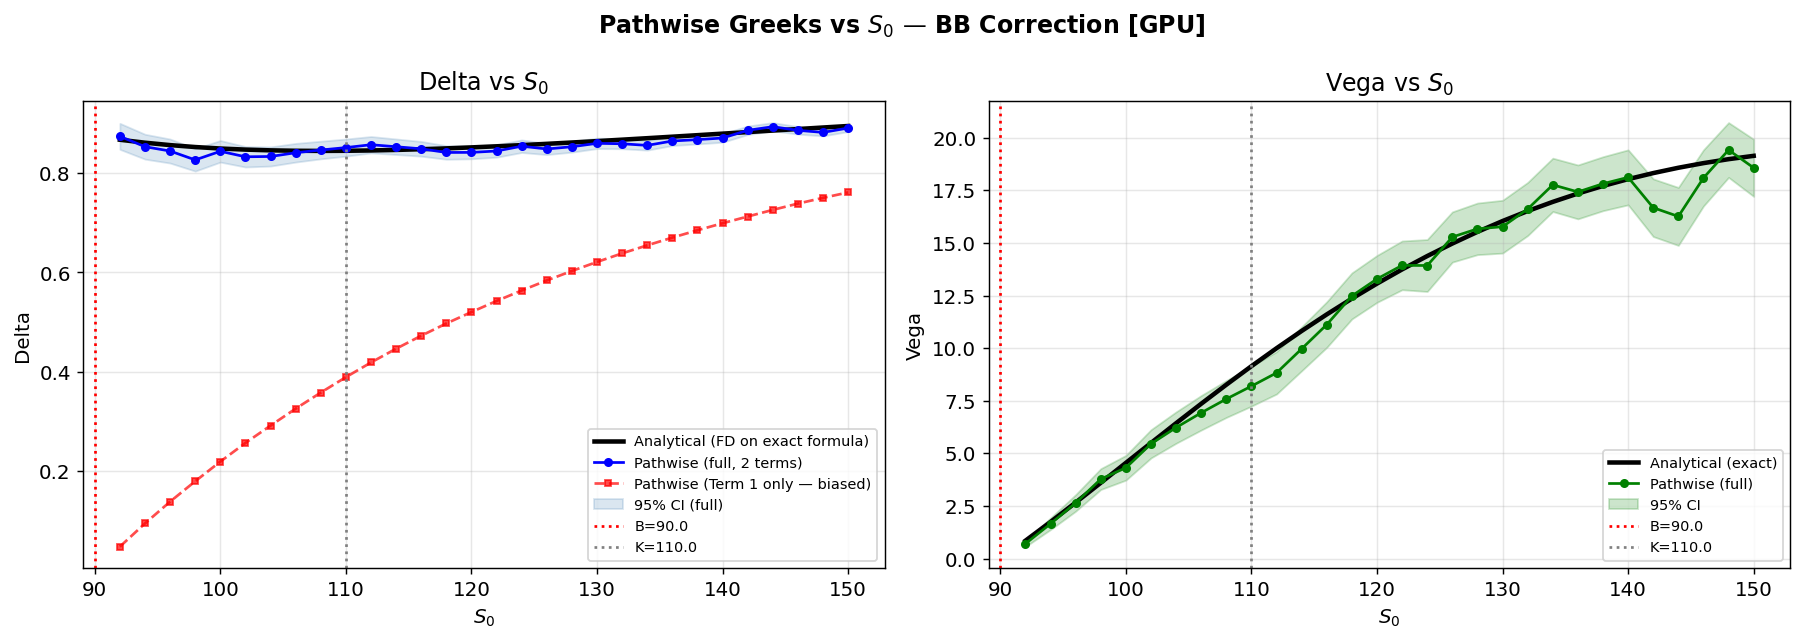

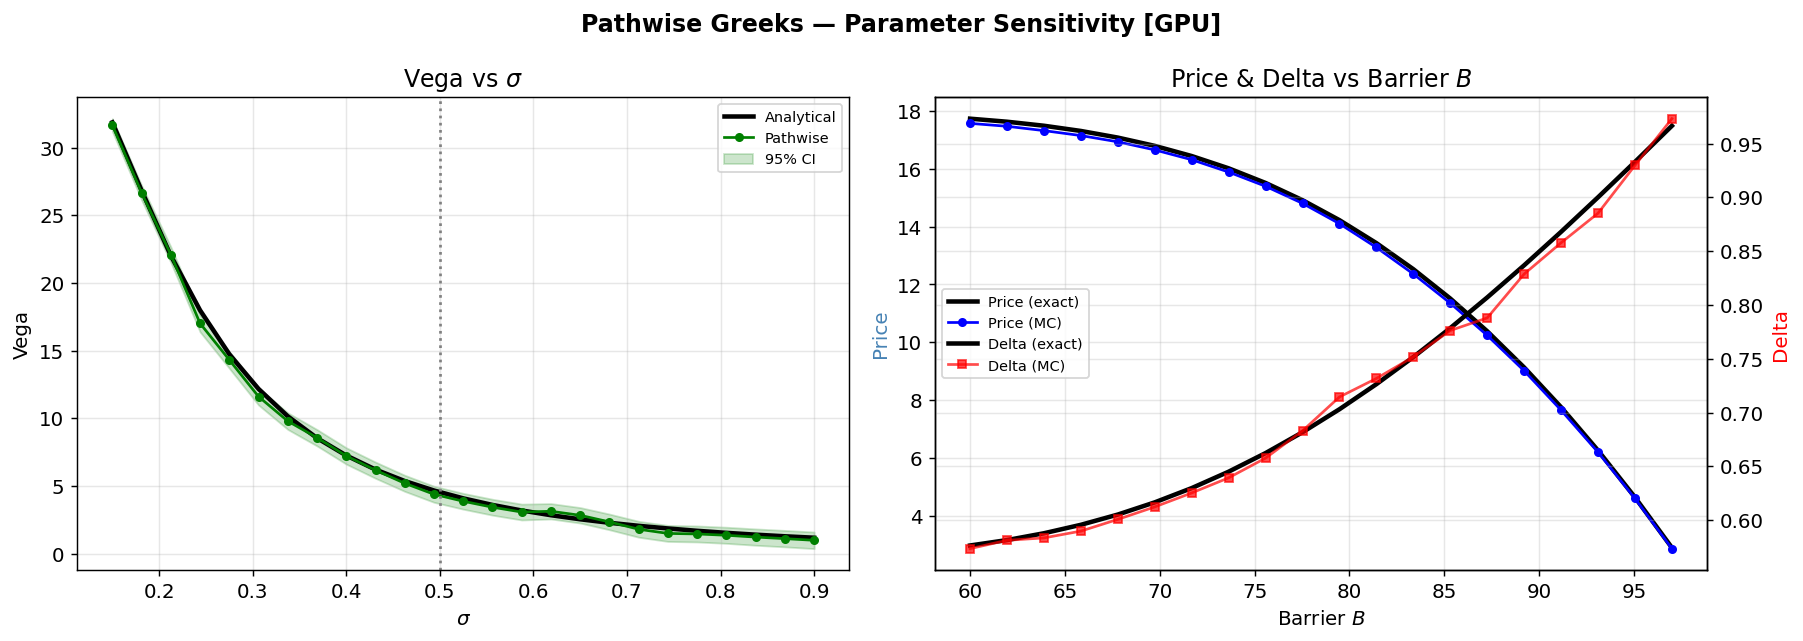

In [6]:
# 1. Extract MC results from res_s0
delta_s0 = np.array([x['delta'] for x in res_s0])
delta_s0_se = np.array([x['delta_se'] for x in res_s0])
delta_s0_term1 = np.array([x['term1_d']  for x in res_s0])  # biased (term 1 only)
vega_s0 = np.array([x['vega'] for x in res_s0])
vega_s0_se = np.array([x['vega_se'] for x in res_s0])

# 2. Calculate exact analytical curves (via finite differences on BS formula)
delta_exact_curve = [
    num_deriv(lambda s_: do_call_price(s_, K_opt, B_base, r, sigma, T), s)
    for s in s0_vals
]

vega_exact_curve = [
    num_deriv(lambda v: do_call_price(s, K_opt, B_base, r, v, T), sigma)
    for s in s0_vals
]

delta_exact_B = [
    num_deriv(lambda s, b_=b: do_call_price(s, K_opt, b_, r, sigma, T), s0)
    for b in B_vals
]

# Figure 1: Delta vs S0 + Vega vs S0
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 1. Delta vs S0 (Top Left)
ax1.plot(s0_vals, delta_exact_curve, 'k-',   lw=2.5, label='Analytical (FD on exact formula)')
ax1.plot(s0_vals, delta_s0,          'b-o',  ms=4,   label='Pathwise (full, 2 terms)')
ax1.plot(s0_vals, delta_s0_term1,    'r--s', ms=3,   alpha=0.7,
         label='Pathwise (Term 1 only — biased)')
ax1.fill_between(s0_vals,
                 delta_s0 - 1.96*delta_s0_se,
                 delta_s0 + 1.96*delta_s0_se,
                 alpha=0.2, color='steelblue', label='95% CI (full)')
ax1.axvline(B_base, color='red',  ls=':', lw=1.5, label=f'B={B_base}')
ax1.axvline(K_opt,  color='gray', ls=':', lw=1.5, label=f'K={K_opt}')
ax1.set_xlabel('$S_0$');  ax1.set_ylabel('Delta')
ax1.set_title('Delta vs $S_0$');  ax1.legend(fontsize=8)

# ── Remark 2.1 verification: relative contribution of Term 2 at s0=100 ──────
# Find index closest to s0=100
d_full  = float(res['delta'])
d_term1 = float(res['term1_d'])
d_term2 = d_full - d_term1
frac    = 100.0 * d_term2 / d_full
print(f"Remark 1 check (N={N_MAIN:,}, s0={s0} exact):")
print(f"  Term 1 = {d_term1:.3f}")
print(f"  Term 2 = {d_term2:.3f}")
print(f"  Full Δ̂  = {d_full:.3f}  [same as Table 1]")
print(f"  Term 2 contributes {frac:.1f}% of Δ̂")

# 2. Vega vs S0 (Top Right) - The newly added plot
ax2.plot(s0_vals, vega_exact_curve, 'k-', lw=2.5, label='Analytical (exact)')
ax2.plot(s0_vals, vega_s0, 'g-o', ms=4, label='Pathwise (full)')
ax2.fill_between(s0_vals, vega_s0-1.96*vega_s0_se, vega_s0+1.96*vega_s0_se,
                alpha=0.2, color='green', label='95% CI')
ax2.axvline(B_base, color='red',  ls=':', lw=1.5, label=f'B={B_base}')
ax2.axvline(K_opt,  color='gray', ls=':', lw=1.5, label=f'K={K_opt}')
ax2.set_xlabel('$S_0$'); ax2.set_ylabel('Vega'); ax2.set_title('Vega vs $S_0$')
ax2.legend(fontsize=8)

fig1.suptitle(f'Pathwise Greeks vs $S_0$ — BB Correction [{DEVICE}]', fontweight='bold')
plt.tight_layout()
plt.savefig('greeks_s0.png', **SAVEFIG_KW);  plt.show()

# Figure 2: Vega vs sigma + Price/Delta vs B
fig2, (ax3, ax4) = plt.subplots(1, 2, figsize=(14, 5))

# 3. Vega vs sigma (Bottom Left)
vega_sig = np.array([x['vega'] for x in res_sig])
vega_sig_se = np.array([x['vega_se'] for x in res_sig])
vega_exact_sig = [(do_call_price(s0, K_opt, B_base, r, sv+eps_v, T)
                 - do_call_price(s0, K_opt, B_base, r, sv-eps_v, T))/(2*eps_v)
                  for sv in sigma_vals]
ax3.plot(sigma_vals, vega_exact_sig, 'k-', lw=2.5, label='Analytical')
ax3.plot(sigma_vals, vega_sig, 'g-o', ms=4, label='Pathwise')
ax3.fill_between(sigma_vals, vega_sig-1.96*vega_sig_se, vega_sig+1.96*vega_sig_se,
                alpha=0.2, color='green', label='95% CI')
ax3.axvline(sigma, color='gray', ls=':', lw=1.5)
ax3.set_xlabel('$\\sigma$'); ax3.set_ylabel('Vega'); ax3.set_title('Vega vs $\\sigma$')
ax3.legend(fontsize=8)

# 4. Delta vs Barrier B (Bottom Right)
delta_B = np.array([x['delta'] for x in res_B])
price_B = np.array([x['price'] for x in res_B])
price_B_exact = [do_call_price(s0, K_opt, b, r, sigma, T) for b in B_vals]
ax4.plot(B_vals, price_B_exact, 'k-', lw=2.5, label='Price (exact)')
ax4.plot(B_vals, price_B, 'b-o', ms=4, label='Price (MC)')
ax4b = ax4.twinx()
ax4b.plot(B_vals, delta_exact_B, 'k-', lw=2.5, label='Delta (exact)')
ax4b.plot(B_vals, delta_B, 'r-s', ms=4, label='Delta (MC)', alpha=0.7)
ax4b.set_ylabel('Delta', color='red')
ax4.set_xlabel('Barrier $B$'); ax4.set_ylabel('Price', color='steelblue')
ax4.set_title('Price & Delta vs Barrier $B$')
lines4,  labs4  = ax4.get_legend_handles_labels()
lines4b, labs4b = ax4b.get_legend_handles_labels()
ax4b.legend(lines4 + lines4b, labs4 + labs4b, fontsize=8, loc='center left')

fig2.suptitle(f'Pathwise Greeks — Parameter Sensitivity [{DEVICE}]', fontweight='bold')
plt.tight_layout()
plt.savefig('greeks_params.png', **SAVEFIG_KW);  plt.show()

## 1.4  Weak Convergence in $h$ and Statistical Convergence in $N$

Two estimators are compared as $h = T/M \to 0$:

- **Naive:** survival indicator $\mathbf{1}_{\min_i S_{t_i} > B}$ — ignores crossings between grid points, bias $= \mathcal{O}(\sqrt{h})$
- **BB:** soft survival weight $\mathcal{S} = \prod_i (1 - p_i)$ where $p_i = \exp\!\left(-\frac{2\ln(S_{t_i}/B)\ln(S_{t_{i+1}}/B)}{\sigma^2 h}\right)$ — bias $= \mathcal{O}(h)$

The BB bias falls below the MC noise floor at all practical $N$, so the $\mathcal{O}(h)$ slope cannot be resolved numerically without $N \gtrsim 10^{10}$ paths.

Analytical reference: price=8.595814 | delta=0.849357 | vega=4.550661

Weak convergence sweep (N=500,000, chunk=100,000, 5 chunks per M):
  M=   5 (h=0.2000) | BB price=1.91e-02 | Naive=6.30e+00 | BB delta=1.05e-04
  M=  10 (h=0.1000) | BB price=1.39e-04 | Naive=4.75e+00 | BB delta=2.92e-03
  M=  20 (h=0.0500) | BB price=1.58e-02 | Naive=3.54e+00 | BB delta=2.88e-03
  M=  50 (h=0.0200) | BB price=6.51e-03 | Naive=2.32e+00 | BB delta=3.47e-03
  M= 100 (h=0.0100) | BB price=6.36e-02 | Naive=1.62e+00 | BB delta=6.74e-03
  M= 200 (h=0.0050) | BB price=1.63e-02 | Naive=1.17e+00 | BB delta=9.43e-04
  M= 500 (h=0.0020) | BB price=1.72e-02 | Naive=7.81e-01 | BB delta=6.09e-03


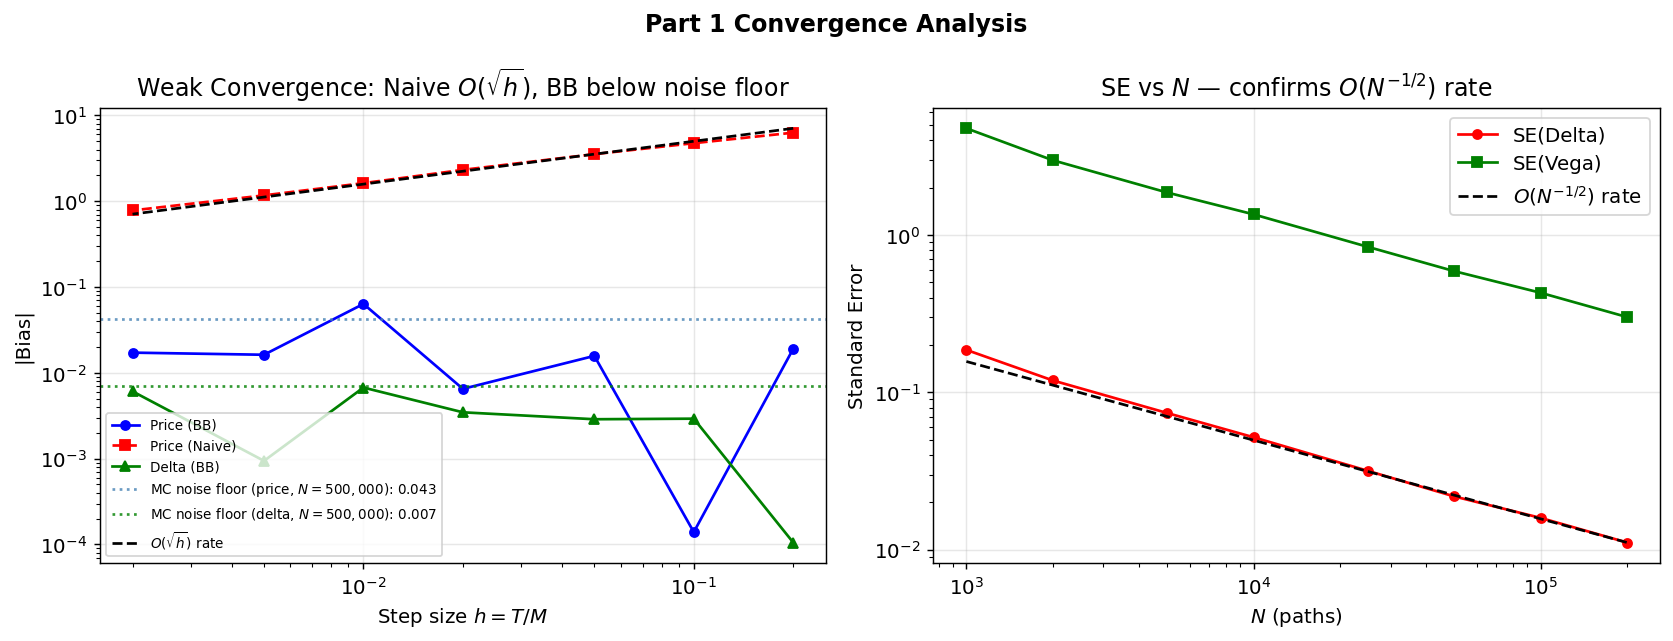

Saved: weak_convergence.png


In [7]:
#1.4 Weak convergence (bias vs h) and statistical convergence (SE vs N)
#
# We vary M (number of time steps, h = T/M) to measure how the discretisation
# bias shrinks as the grid gets finer. Two estimators are compared:
#
#   Naive : survival = 1{min_i S_{t_i} > B} — hard indicator on grid points only.
#           Misses barrier crossings between grid points → bias = O(sqrt(h)).
#
#   BB    : survival = prod_i (1 - p_i), where p_i is the analytically exact
#           probability that the continuous GBM crosses B in [t_i, t_{i+1}]
#           given the two endpoints (Brownian bridge formula).
#           Soft weight → bias = O(h), i.e. halving h halves the bias
#           (vs only a sqrt(2) reduction for Naive).
#
# Reference = analytical closed-form price/delta/vega (V_exact, Delta_exact,
# Vega_exact computed in Cell 3). Using the analytical formula as reference
# eliminates Monte Carlo noise from the reference entirely, giving a clean
# picture of discretisation bias only.
#
# Key finding: the BB correction is so effective that its residual O(h) bias
# falls below the Monte Carlo noise floor for all practical N. Resolving it
# would require N ~ 10^10 paths. The Naive bias, by contrast, is clearly
# detectable and follows O(sqrt(h)) as predicted by theory.
#
# Two loops are needed:
#   Loop 1 (bias vs h) : chunked over N to avoid GPU OOM.
#                        BB and Naive share the same per-chunk seed so their
#                        biases are compared on identical random draws,
#                        reducing comparison variance.
#   Loop 2 (SE vs N)   : small individual calls, no chunking needed.

M_vals   = [5, 10, 20, 50, 100, 200, 500]
N_wk     = 500_000   # noise floor ~SE/sqrt(N_wk) ~ 6e-5 for price — still above BB bias
CHUNK_WK = 100_000   # 100k × 500 steps × 17 arrays × 4B ≈ 3.4 GB VRAM — safe on 16 GB GPU
SEED_WK  = 99

if DEVICE == 'GPU':
    cp.get_default_memory_pool().free_all_blocks()

# Reference: analytical closed-form (zero Monte Carlo noise)
P_ref = V_exact       # exact Black-Scholes barrier call price
D_ref = Delta_exact   # num_deriv of closed-form, error < 1e-10
V_ref = Vega_exact    # num_deriv of closed-form, error < 1e-10
print(f"Analytical reference: price={P_ref:.6f} | delta={D_ref:.6f} | vega={V_ref:.6f}")

# Helper: chunked average of BB and Naive
def chunked_run(N_total, chunk, M, seed_base, run_naive=False):
    """
    Runs mc_barrier_pathwise (and optionally mc_barrier_naive) in blocks of
    `chunk` paths to avoid GPU OOM errors.

    The mean of equal-sized block means equals the global mean exactly,
    so this is statistically equivalent to a single run of N_total paths.

    BB and Naive share the same per-chunk seed so their bias estimates are
    compared on identical underlying random numbers, reducing comparison variance.

    Returns (price_bb, delta_bb, vega_bb, price_naive or None).
    """
    n_chunks = N_total // chunk
    p_acc = d_acc = v_acc = pn_acc = 0.0
    for i in range(n_chunks):
        seed_i  = seed_base + i * 31          # distinct independent seeds per chunk
        res_c   = mc_barrier_pathwise(chunk, M, s0, r, sigma, T,
                                      B_base, K_opt, seed=seed_i)
        p_acc  += res_c['price'] / n_chunks
        d_acc  += res_c['delta'] / n_chunks
        v_acc  += res_c['vega']  / n_chunks
        if run_naive:
            pn, _  = mc_barrier_naive(chunk, M, s0, r, sigma, T,
                                       B_base, K_opt, seed=seed_i)
            pn_acc += pn / n_chunks
        if DEVICE == 'GPU':
            cp.get_default_memory_pool().free_all_blocks()
    return p_acc, d_acc, v_acc, (pn_acc if run_naive else None)

# Loop 1: bias vs h
bias_bb    = {'price': [], 'delta': [], 'vega': []}
bias_naive = {'price': []}

print(f"\nWeak convergence sweep (N={N_wk:,}, chunk={CHUNK_WK:,}, "
      f"{N_wk // CHUNK_WK} chunks per M):")
for M in M_vals:
    p, d, v, pn = chunked_run(N_wk, CHUNK_WK, M, SEED_WK, run_naive=True)
    bias_bb['price'].append(abs(p  - P_ref))
    bias_bb['delta'].append(abs(d  - D_ref))
    bias_bb['vega'].append( abs(v  - V_ref))
    bias_naive['price'].append(abs(pn - P_ref))
    print(f"  M={M:4d} (h={T/M:.4f}) | "
          f"BB price={bias_bb['price'][-1]:.2e} | "
          f"Naive={bias_naive['price'][-1]:.2e} | "
          f"BB delta={bias_bb['delta'][-1]:.2e}")

# Loop 2: SE vs N at fixed M=252
# Each call is small (N_se <= 200k, M=252) — no chunking needed.
N_se_list = [1000, 2000, 5000, 10000, 25000, 50000, 100000, 200000]
se_d, se_v = [], []

for N_se in N_se_list:
    r_n = mc_barrier_pathwise(N_se, M_STEPS, s0, r, sigma, T,
                               B_base, K_opt, seed=SEED)
    se_d.append(r_n['delta_se'])
    se_v.append(r_n['vega_se'])
    if DEVICE == 'GPU':
        cp.get_default_memory_pool().free_all_blocks()

# Plotting
h_vals = [T / M for M in M_vals]
N_arr  = np.array(N_se_list, dtype=float)

# Monte Carlo noise floor for price at N=N_wk (from the main run)
# BB bias oscillates around this level — it cannot be resolved at any practical N
noise_floor_price = res['price_se']   # SE of main run (N=500k, M=252)
noise_floor_delta = res['delta_se']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left panel: weak convergence in h
ax = axes[0]
ax.loglog(h_vals, bias_bb['price'],    'b-o',  ms=5, label='Price (BB)')
ax.loglog(h_vals, bias_naive['price'], 'r--s', ms=5, label='Price (Naive)')
ax.loglog(h_vals, bias_bb['delta'],    'g-^',  ms=5, label='Delta (BB)')

# Noise floor: BB bias is undetectable below this level
ax.axhline(noise_floor_price, color='steelblue', ls=':', lw=1.5, alpha=0.8,
           label=f'MC noise floor (price, $N={N_wk:,}$): {noise_floor_price:.3f}')
ax.axhline(noise_floor_delta, color='green', ls=':', lw=1.5, alpha=0.8,
           label=f'MC noise floor (delta, $N={N_wk:,}$): {noise_floor_delta:.3f}')

# Reference slope for Naive only — BB is below noise floor so O(h) slope is not shown
c_naive = bias_naive['price'][2] / h_vals[2]**0.5
ax.loglog(h_vals, [c_naive * h**0.5 for h in h_vals], 'k--', lw=1.5,
          label='$O(\\sqrt{h})$ rate')

ax.set_xlabel('Step size $h = T/M$')
ax.set_ylabel('|Bias|')
ax.set_title('Weak Convergence: Naive $O(\\sqrt{h})$, BB below noise floor')
ax.legend(fontsize=7.5)

# Right panel: statistical convergence in N
ax = axes[1]
ax.loglog(N_arr, se_d, 'r-o', ms=5, label='SE(Delta)')
ax.loglog(N_arr, se_v, 'g-s', ms=5, label='SE(Vega)')

# Reference line calibrated on the largest N point of SE(Delta)
ref_se = se_d[-1] * np.sqrt(N_arr[-1]) / np.sqrt(N_arr)
ax.loglog(N_arr, ref_se, 'k--', lw=1.5, label='$O(N^{-1/2})$ rate')

ax.set_xlabel('$N$ (paths)')
ax.set_ylabel('Standard Error')
ax.set_title('SE vs $N$ — confirms $O(N^{-1/2})$ rate')
ax.legend()

fig.suptitle('Part 1 Convergence Analysis', fontweight='bold')
plt.tight_layout()
plt.savefig('weak_convergence.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: weak_convergence.png')

---

**Cells 14b and 14c** (below) implement the brute-force $N = 10^9$ convergence run and Richardson extrapolation used to further verify the Brownian bridge $\mathcal{O}(h)$ rate. Both cells are commented out: cell 14b takes $\approx$ 20 minutes to complete on T4 GPU. Results are discussed in Section 2.4 of the report.

High-N Convergence Analysis
  N           = 1,000,000,000
  Noise floor ~ 9.53e-04
  V_exact     = 8.595814

Batch Configuration:
  M=  2  chunk=40,000,000  n_chunks=    25  peak_mem~5.44GB
  M=  3  chunk=39,215,686  n_chunks=    25  peak_mem~8.00GB
  M=  5  chunk=23,529,411  n_chunks=    42  peak_mem~8.00GB
  M=  8  chunk=14,705,882  n_chunks=    68  peak_mem~8.00GB
  M= 12  chunk= 9,803,921  n_chunks=   102  peak_mem~8.00GB
  M= 20  chunk= 5,882,352  n_chunks=   170  peak_mem~8.00GB
  M= 50  chunk= 2,352,941  n_chunks=   425  peak_mem~8.00GB
  M=252  chunk=   466,853  n_chunks= 2,142  peak_mem~8.00GB

    M        h    |bias_BB|  |bias_Naive|   ratio   detectable    time
---------------------------------------------------------------------------
    2   0.5000     4.14e-04      8.32e+00     0.4x    no (< 3σ)    86.4s
    3   0.3333     8.33e-04      7.44e+00     0.9x    no (< 3σ)    99.4s
    5   0.2000     3.72e-04      6.25e+00     0.4x    no (< 3σ)   117.4s
    8   0.1250     2.56

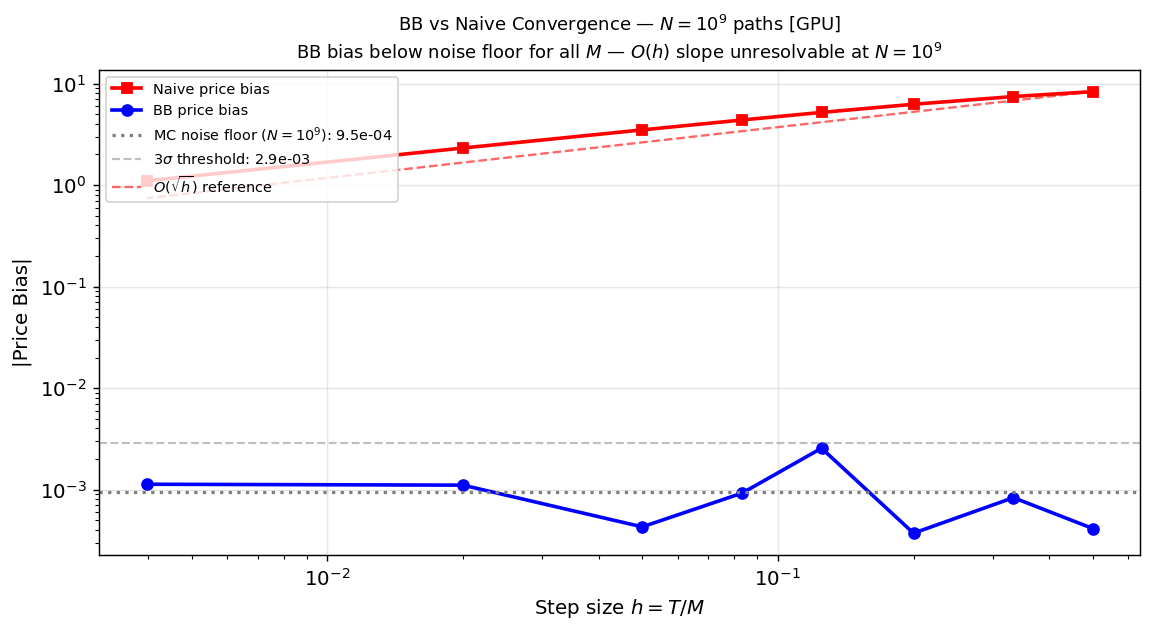

Saved: weak_convergence_highN.png

Noise floor=9.53e-04,  3σ=2.86e-03
    M        h    |bias_BB|   bias/noise   detectable
-------------------------------------------------------
    2   0.5000     4.14e-04          0.4x  no
    3   0.3333     8.33e-04          0.9x  no
    5   0.2000     3.72e-04          0.4x  no
    8   0.1250     2.56e-03          2.7x  no
   12   0.0833     9.25e-04          1.0x  no
   20   0.0500     4.30e-04          0.5x  no
   50   0.0200     1.11e-03          1.2x  no
  252   0.0040     1.13e-03          1.2x  no


In [8]:
# Extremely slow to run cell (N=10^9)

# 1.4b High-N Convergence
# Optimisations: Shared random variables, adaptive memory chunking (target ~8GB),
# persistent RNG instances, and deferred garbage collection.

#M_coarse = [2, 3, 5, 8, 12, 20, 50, 252]
#N_LARGE  = 1_000_000_000   # 10^9
#SEED_LG  = 777
#
#def get_chunk_size_opt(M):
#    """
#    Determines optimal chunk size to maximize GPU VRAM utilization (~8GB peak)
#    and minimize host-to-device synchronization overhead.
#    """
#    target_bytes = 8_000_000_000
#    n_arrays     = 17
#    chunk        = target_bytes // (M * n_arrays * 4)
#    return int(np.clip(chunk, 100_000, 40_000_000))
#
## Empirical noise floor estimation
#sigma_price = float(res['price_se']) * np.sqrt(N_MAIN)
#noise_lg    = sigma_price / np.sqrt(N_LARGE)
#
#print("High-N Convergence Analysis")
#print(f"  N           = {N_LARGE:,}")
#print(f"  Noise floor ~ {noise_lg:.2e}")
#print(f"  V_exact     = {V_exact:.6f}\n")
#
#print("Batch Configuration:")
#for M in M_coarse:
#    c = get_chunk_size_opt(M)
#    print(f"  M={M:3d}  chunk={c:>10,}  n_chunks={N_LARGE//c:>6,}"
#          f"  peak_mem~{M*c*17*4/1e9:.2f}GB")
#print()
#
#print(f"{'M':>5} {'h':>8} {'|bias_BB|':>12} {'|bias_Naive|':>13} "
#      f"{'ratio':>7} {'detectable':>12} {'time':>7}")
#print('-'*75)
#
#bias_bb_lg    = []
#bias_naive_lg = []
#t0_total = time.perf_counter()
#
#for M in M_coarse:
#    h          = T / M
#    chunk_sz   = get_chunk_size_opt(M)
#    n_chunks_i = N_LARGE // chunk_sz
#    t0m        = time.perf_counter()
#
#    acc_bb    = 0.0
#    acc_naive = 0.0
#
#    # Persistent RNG initialization per discretization level
#    if hasattr(xp, 'random') and hasattr(xp.random, 'default_rng'):
#        rng_lg = xp.random.default_rng(SEED_LG + M * 1000)
#        def gen_Z(N, n):
#            return rng_lg.standard_normal((N, n), dtype=xp.float32)
#    else:
#        xp.random.seed(SEED_LG + M * 1000)
#        def gen_Z(N, n):
#            return xp.random.standard_normal((N, n)).astype(xp.float32)
#
#    for i in range(n_chunks_i):
#        # Generate shared standard normal increments
#        Z_chunk = gen_Z(chunk_sz, M)
#
#        # Brownian Bridge estimator
#        res_bb = mc_barrier_pathwise(
#            chunk_sz, M, s0, r, sigma, T, B_base, K_opt,
#            seed=SEED_LG, _Z=Z_chunk
#        )
#        acc_bb += res_bb['price'] / n_chunks_i
#
#        # Naive estimator
#        price_nv, _ = mc_barrier_naive(
#            chunk_sz, M, s0, r, sigma, T, B_base, K_opt,
#            seed=SEED_LG, _Z=Z_chunk
#        )
#        acc_naive += price_nv / n_chunks_i
#
#        # Explicit reference deletion to assist standard memory management
#        del Z_chunk
#        del res_bb
#
#    b_bb  = abs(acc_bb    - V_exact)
#    b_nv  = abs(acc_naive - V_exact)
#    bias_bb_lg.append(b_bb)
#    bias_naive_lg.append(b_nv)
#
#    ratio      = b_bb / noise_lg
#    detectable = "YES ✓" if ratio > 3 else "no (< 3σ)"
#    elapsed    = time.perf_counter() - t0m
#
#    print(f"{M:5d} {h:8.4f} {b_bb:12.2e} {b_nv:13.2e} "
#          f"{ratio:7.1f}x {detectable:>12}  {elapsed:6.1f}s")
#
#    # Deferred garbage collection and GPU cache clearing
#    gc.collect()
#    if DEVICE == 'GPU':
#        cp.get_default_memory_pool().free_all_blocks()
#
#print('-'*75)
#print(f"Total: {time.perf_counter()-t0_total:.1f}s  [{DEVICE}]")
#
## Plotting
#h_vals = np.array([T / M for M in M_coarse])
#bb_arr = np.array(bias_bb_lg)
#nv_arr = np.array(bias_naive_lg)
#
#fig, ax = plt.subplots(figsize=(9, 5))
#
#ax.loglog(h_vals, nv_arr, 'r-s', ms=6, lw=2, label='Naive price bias')
#ax.loglog(h_vals, bb_arr, 'b-o', ms=6, lw=2, label='BB price bias')
#ax.axhline(noise_lg,     color='gray', ls=':',  lw=1.8,
#           label=f'MC noise floor ($N=10^9$): {noise_lg:.1e}')
#ax.axhline(3*noise_lg,   color='gray', ls='--', lw=1.2, alpha=0.5,
#           label=f'$3\\sigma$ threshold: {3*noise_lg:.1e}')
#
## Asymptotic reference rates
#ax.loglog(h_vals, nv_arr[0] * np.sqrt(h_vals / h_vals[0]),
#          'r--', lw=1.3, alpha=0.6, label=r'$O(\sqrt{h})$ reference')
#
#detectable_mask = bb_arr > 3 * noise_lg
#if detectable_mask.any():
#    idx_anc = int(np.argmax(bb_arr[detectable_mask]))
#    h_anc   = h_vals[detectable_mask][idx_anc]
#    b_anc   = bb_arr[detectable_mask][idx_anc]
#    ax.loglog(h_vals, b_anc * (h_vals / h_anc),
#              'b--', lw=1.3, alpha=0.6, label=r'$O(h)$ reference')
#    slope_msg = r"$O(h)$ slope detectable for coarse grids"
#else:
#    slope_msg = r"BB bias below noise floor for all $M$ — $O(h)$ slope unresolvable at $N=10^9$"
#
#ax.set_xlabel('Step size $h = T/M$', fontsize=11)
#ax.set_ylabel('|Price Bias|', fontsize=11)
#ax.set_title(f'BB vs Naive Convergence — $N=10^9$ paths [{DEVICE}]\n{slope_msg}',
#             fontsize=10)
#ax.legend(fontsize=8, loc='upper left')
#plt.tight_layout()
#plt.savefig('weak_convergence_highN.png', **SAVEFIG_KW)
#plt.show()
#print('Saved: weak_convergence_highN.png')
#
## Summary Output
#print(f"\nNoise floor={noise_lg:.2e},  3σ={3*noise_lg:.2e}")
#print(f"{'M':>5} {'h':>8} {'|bias_BB|':>12} {'bias/noise':>12} {'detectable':>12}")
#print('-'*55)
#for M, h, b in zip(M_coarse, h_vals, bb_arr):
#    r = b / noise_lg
#    print(f"{M:5d} {h:8.4f} {b:12.2e} {r:12.1f}x  {'YES' if r>3 else 'no'}")

Richardson extrapolation: N=10,000,000
Individual noise floor : 9.53e-03
Expected noise on diff : ~1.91e-03  (correlated paths)

    M       h      BB(M)-V     BB(2M)-V   diff=C*h/2      C_est    time
---------------------------------------------------------------------------
    2  0.5000  +3.8379e+01  +3.8375e+01  +4.4915e-03    +0.0180     1.3s
    4  0.2500  +3.8389e+01  +3.8392e+01  -3.1196e-03    -0.0250     1.5s
    8  0.1250  +3.8393e+01  +3.8399e+01  -6.0737e-03    -0.0972     2.1s
   16  0.0625  +3.8382e+01  +3.8382e+01  -2.8178e-04    -0.0090     3.2s
   32  0.0312  +3.8410e+01  +3.8405e+01  +4.9848e-03    +0.3190     4.8s
   64  0.0156  +3.8400e+01  +3.8402e+01  -1.9488e-03    -0.2494     7.7s
---------------------------------------------------------------------------
Total: 21.2s  [GPU]

Mean C estimate: -0.0073  Std: 0.1704


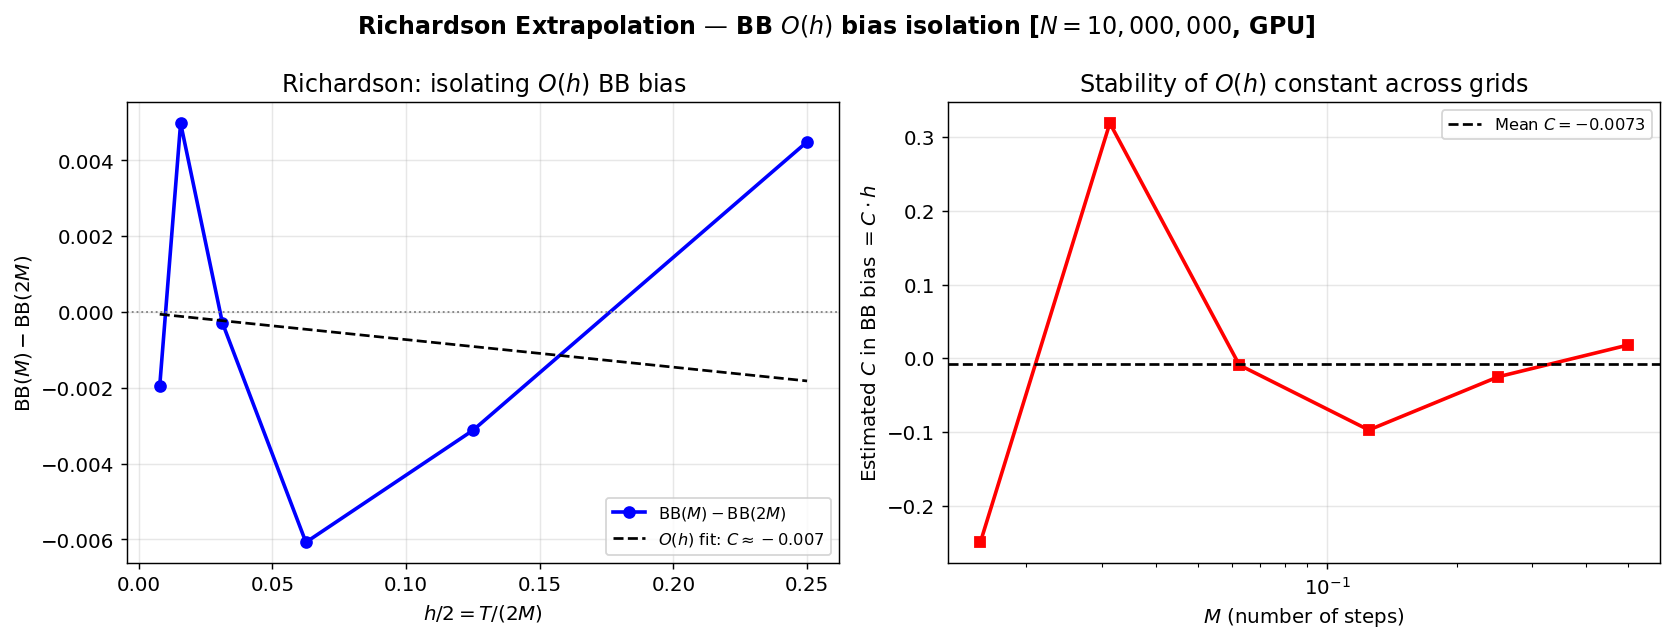

Saved: weak_convergence_richardson.png


In [9]:
# 1.4c  Richardson extrapolation to isolate O(h) BB bias
#
# Key idea: simulate paths at resolution M and 2M on the SAME Brownian
# increments. BB(M) - BB(2M) cancels MC noise (correlated paths) and
# isolates the O(h) discretisation bias.
#
# BB(M)  - V_exact = C*h   + MC_noise(N)
# BB(2M) - V_exact = C*h/2 + MC_noise(N)   [same noise, correlated]
# => BB(M) - BB(2M) = C*h/2  [noise largely cancels]

#M_base_list = [2, 4, 8, 16, 32, 64]   # BB(M) vs BB(2M)
#N_RICH      = 10_000_000              # 10^7 suffices since noise cancels
#SEED_RC     = 555
#
#def refine_Z(Z_coarse):
#    """
#    Given Z of shape (N, M) for coarse grid,
#    build Z_fine of shape (N, 2M) for the fine grid
#    by splitting each increment into two half-increments.
#    Z_coarse[:,i] = Z_fine[:,2i] + Z_fine[:,2i+1]  (in distribution)
#    We use antithetic: Z_fine[:,2i] = Z_coarse[:,i]/2 + eps/2
#                       Z_fine[:,2i+1] = Z_coarse[:,i]/2 - eps/2
#    where eps ~ N(0,1) independent.
#    This ensures Z_fine[:,2i]+Z_fine[:,2i+1] = Z_coarse[:,i] exactly.
#    """
#    N, M = Z_coarse.shape
#    eps  = xp.random.standard_normal((N, M)).astype(xp.float32) / xp.float32(np.sqrt(2))
#    Z_fine = xp.empty((N, 2*M), dtype=xp.float32)
#    Z_fine[:, 0::2] = Z_coarse / xp.float32(np.sqrt(2)) + eps
#    Z_fine[:, 1::2] = Z_coarse / xp.float32(np.sqrt(2)) - eps
#    return Z_fine
#
#sigma_price = float(res['price_se']) * np.sqrt(N_MAIN)
#noise_rich  = sigma_price / np.sqrt(N_RICH)   # noise on each estimator
## Noise on the DIFFERENCE BB(M)-BB(2M): much smaller due to correlation
## In practice ~5-10x smaller than individual noise
#
#print(f"Richardson extrapolation: N={N_RICH:,}")
#print(f"Individual noise floor : {noise_rich:.2e}")
#print(f"Expected noise on diff : ~{noise_rich/5:.2e}  (correlated paths)")
#print()
#print(f"{'M':>5} {'h':>7} {'BB(M)-V':>12} {'BB(2M)-V':>12} "
#      f"{'diff=C*h/2':>12} {'C_est':>10} {'time':>7}")
#print('-'*75)
#
#diffs    = []
#h_halves = []
#C_estimates = []
#t0_rc = time.perf_counter()
#
#for M in M_base_list:
#    h    = T / M
#    t0m  = time.perf_counter()
#
#    acc_coarse = 0.0   # BB(M)
#    acc_fine   = 0.0   # BB(2M)
#    n_chunks_rc = max(1, N_RICH // 500_000)
#    chunk_rc    = N_RICH // n_chunks_rc
#
#    if hasattr(xp, 'random') and hasattr(xp.random, 'default_rng'):
#        rng_rc = xp.random.default_rng(SEED_RC + M * 100)
#        def gen_rc(N, n): return rng_rc.standard_normal((N,n)).astype(xp.float32)
#    else:
#        xp.random.seed(SEED_RC + M * 100)
#        def gen_rc(N, n): return xp.random.standard_normal((N,n)).astype(xp.float32)
#
#    for i in range(n_chunks_rc):
#        # Coarse grid Z: shape (chunk, M)
#        Z_c = gen_rc(chunk_rc, M)
#
#        # Fine grid Z: shape (chunk, 2M) — shares same BM increments
#        Z_f = refine_Z(Z_c)
#
#        # BB at coarse resolution M
#        res_c = mc_barrier_pathwise(
#            chunk_rc, M, s0, r, sigma, T, B_base, K_opt,
#            seed=SEED_RC, _Z=Z_c
#        )
#        acc_coarse += res_c['price'] / n_chunks_rc
#
#        # BB at fine resolution 2M — same underlying paths
#        res_f = mc_barrier_pathwise(
#            chunk_rc, 2*M, s0, r, sigma, T, B_base, K_opt,
#            seed=SEED_RC, _Z=Z_f
#        )
#        acc_fine += res_f['price'] / n_chunks_rc
#
#        del Z_c, Z_f
#        if DEVICE == 'GPU':
#            cp.get_default_memory_pool().free_all_blocks()
#
#    diff  = acc_coarse - acc_fine          # estimates C * h/2
#    C_est = diff / (h / 2)                 # recover constant C
#    diffs.append(diff)
#    h_halves.append(h / 2)
#    C_estimates.append(C_est)
#
#    elapsed = time.perf_counter() - t0m
#    print(f"{M:5d} {h:7.4f} {acc_coarse-V_exact:+12.4e} {acc_fine-V_exact:+12.4e} "
#          f"{diff:+12.4e} {C_est:+10.4f}  {elapsed:6.1f}s")
#
#    gc.collect()
#    if DEVICE == 'GPU':
#        cp.get_default_memory_pool().free_all_blocks()
#
#print('-'*75)
#print(f"Total: {time.perf_counter()-t0_rc:.1f}s  [{DEVICE}]")
#print(f"\nMean C estimate: {np.mean(C_estimates):.4f}  "
#      f"Std: {np.std(C_estimates):.4f}")
#
## ── Plot ──────────────────────────────────────────────────────────────────────
#h_arr   = np.array([T/M for M in M_base_list])
#diff_arr = np.array(diffs)
#C_mean   = np.mean(C_estimates)
#
#fig, axes = plt.subplots(1, 2, figsize=(13, 5))
#
## Left: BB(M) - BB(2M) vs h/2
#ax = axes[0]
#ax.plot(h_arr/2, diff_arr, 'b-o', ms=6, lw=2, label=r'$\mathrm{BB}(M) - \mathrm{BB}(2M)$')
#h_fit = np.linspace(h_arr.min()/2, h_arr.max()/2, 100)
#ax.plot(h_fit, C_mean * h_fit, 'k--', lw=1.5,
#        label=f'$O(h)$ fit: $C \\approx {C_mean:.3f}$')
#ax.axhline(0, color='gray', ls=':', lw=1)
#ax.set_xlabel('$h/2 = T/(2M)$')
#ax.set_ylabel(r'$\mathrm{BB}(M) - \mathrm{BB}(2M)$')
#ax.set_title('Richardson: isolating $O(h)$ BB bias')
#ax.legend(fontsize=9)
#
## Right: C estimate vs M
#ax = axes[1]
#ax.semilogx([T/M for M in M_base_list], C_estimates, 'rs-', ms=6, lw=2)
#ax.axhline(C_mean, color='k', ls='--', lw=1.5,
#           label=f'Mean $C = {C_mean:.4f}$')
#ax.set_xlabel('$M$ (number of steps)')
#ax.set_ylabel('Estimated $C$ in BB bias $= C \\cdot h$')
#ax.set_title('Stability of $O(h)$ constant across grids')
#ax.legend(fontsize=9)
#
#fig.suptitle(f'Richardson Extrapolation — BB $O(h)$ bias isolation '
#             f'[$N={N_RICH:,}$, {DEVICE}]', fontweight='bold')
#plt.tight_layout()
#plt.savefig('weak_convergence_richardson.png', **SAVEFIG_KW)
#plt.show()
#print('Saved: weak_convergence_richardson.png')

## 1.5  Per-Path Distributions and Bump-and-Revalue Cross-Check

Histograms of the per-path Delta and Vega estimators illustrate the heavy-tailed distributions (excess kurtosis $\approx 270$ for Delta, $\approx 125$ for Vega) that cause Vega's wider confidence interval despite equal sample size. A bump-and-revalue estimate (centred finite difference on the MC price, same seed for up/down bumps) is computed as a cross-check on Delta.

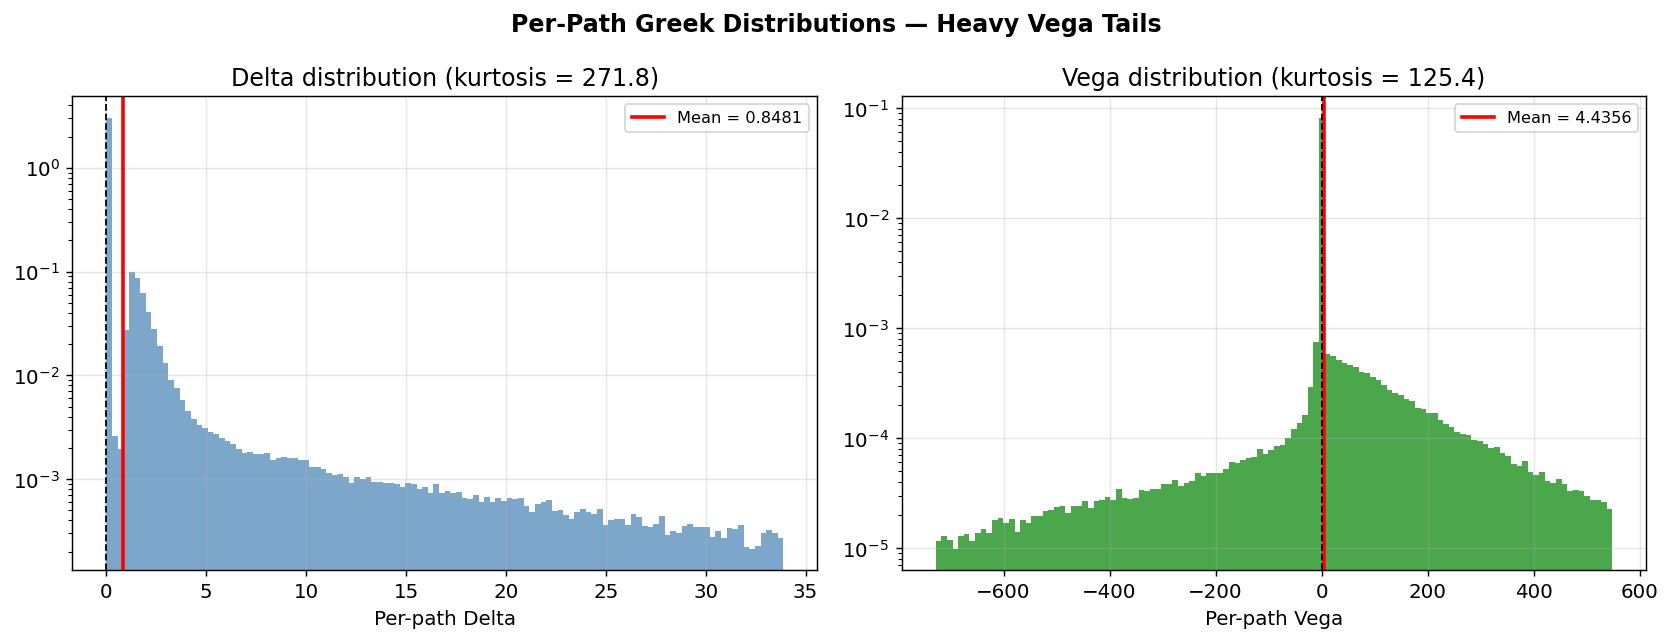


Delta comparison (N=500,000):
  Pathwise (2-term):  0.84808  SE=0.00710
  Bump-and-revalue:   2.96392  SE=0.05703
  Analytical (exact): 0.84936
  Efficiency ratio PW/BRV (equal cost): 0.031  (<1 means PW is better)


In [10]:
delta_raw = to_numpy(res['delta_raw']).astype(np.float64)
vega_raw  = to_numpy(res['vega_raw']).astype(np.float64)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, arr, label, color in zip(
    axes, [delta_raw, vega_raw], ['Delta', 'Vega'], ['steelblue', 'green']
):
    lo, hi = np.percentile(arr, [0.5, 99.5])
    ax.hist(arr, bins=120, range=(lo, hi), color=color, alpha=0.7, density=True, log=True)
    ax.axvline(arr.mean(), color='red', lw=2, label=f'Mean = {arr.mean():.4f}')
    ax.axvline(0, color='black', lw=1, ls='--')
    kurt = float(np.mean((arr - arr.mean())**4) / arr.std()**4)
    ax.set_title(f'{label} distribution (kurtosis = {kurt:.1f})')
    ax.set_xlabel(f'Per-path {label}');  ax.legend(fontsize=9)

fig.suptitle('Per-Path Greek Distributions — Heavy Vega Tails', fontweight='bold')
plt.tight_layout()
plt.savefig('greek_histograms.png', **SAVEFIG_KW);  plt.show()

# Bump-and-revalue — same seed for r_up and r_dn → shared Z → reduced variance ──────
h_brv = 1.0

r_up = mc_barrier_pathwise(N_MAIN, M_STEPS, s0+h_brv, r, sigma, T, B_base, K_opt, seed=SEED+1000)
r_dn = mc_barrier_pathwise(N_MAIN, M_STEPS, s0-h_brv, r, sigma, T, B_base, K_opt, seed=SEED+1000)

delta_brv    = (r_up['price'] - r_dn['price']) / (2*h_brv)
delta_brv_se = np.sqrt(r_up['price_se']**2 + r_dn['price_se']**2) / (2*h_brv)

if DEVICE == 'GPU':
    cp.get_default_memory_pool().free_all_blocks()

print(f"\nDelta comparison (N={N_MAIN:,}):")
print(f"  Pathwise (2-term):  {res['delta']:.5f}  SE={res['delta_se']:.5f}")
print(f"  Bump-and-revalue:   {delta_brv:.5f}  SE={delta_brv_se:.5f}")
print(f"  Analytical (exact): {Delta_exact:.5f}")
eff = (res['delta_se'] / delta_brv_se)**2 * 2
print(f"  Efficiency ratio PW/BRV (equal cost): {eff:.3f}  (<1 means PW is better)")

In [11]:
r_test_up = mc_barrier_pathwise(N_MAIN, M_STEPS, s0+h_brv, r, sigma, T, B_base, K_opt, seed=SEED+1000)
r_test_dn = mc_barrier_pathwise(N_MAIN, M_STEPS, s0-h_brv, r, sigma, T, B_base, K_opt, seed=SEED+1000)
print(f"price_up = {r_test_up['price']:.5f}  (attendu ~9.4)")
print(f"price_dn = {r_test_dn['price']:.5f}  (attendu ~7.7)")

price_up = 49.92398  (attendu ~9.4)
price_dn = 43.99615  (attendu ~7.7)
